# Exercise 4 — Dimensionality Reduction

## Part A — Why Do We Need Dimensionality Reduction?

Real datasets often contain many features.

Example:
```
apartment:
- size
- number of rooms
- floor
- location score
- age
- distance to center
- noise level
- energy consumption
...
```

As the number of features increases:

* visualization becomes difficult
* models become slower
* features may become redundant
* noise increases
* overfitting becomes easier

This is related to: `the curse of dimensionality`

### Goal of Dimensionality Reduction

Reduce the number of features while preserving the important structure of the data.

### Main Idea

Instead of describing the data with many correlated features: `(size, rooms, floor, age, ...)` we create: `new compact features` called `principal components`.

If two features contain similar information: `size ↔ number of rooms` then we may not need both.

PCA tries to find:

* the main directions of variation
* the most informative axes

## Part B — Generate Correlated Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Apartment example
n = 120

size = np.random.normal(70, 15, n)

rooms = size / 25 + np.random.normal(0, 0.35, n)

X = np.column_stack([size, rooms])

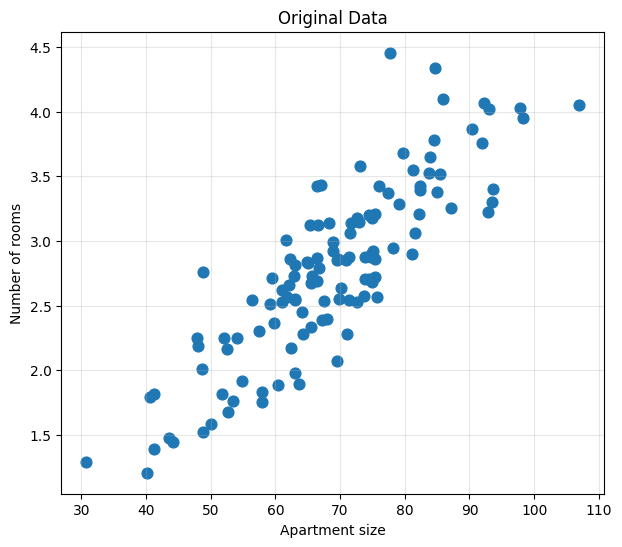

In [2]:
plt.figure(figsize=(7,6))

plt.scatter(X[:,0], X[:,1], s=60)

plt.xlabel("Apartment size")
plt.ylabel("Number of rooms")

plt.title("Original Data")

plt.grid(True, alpha=0.3)

plt.show()

### Questions

1. Are the features correlated?
    -> This is correlated because when the appartment size increase, the number room also can increase to 
2. Does the cloud follow a direction?
    -> Yes, it app go up to the left
3. Could one feature approximately predict the other?
    -> No, At one appartement size, it can have a lot of option room

## Part C — Apply PCA

Standardize the data. Why do we need to do this?

Data standardization is the process of scaling variables so they have a mean of 0 and a standard deviation 1. It is a mandatory first step in PCA to prevent features with larger units or magnitudes from disproportionately dominating the analysis.

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Run PCA

In [4]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Explained Variance

In [5]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.92920937 0.07079063]


`PC1 = direction with maximum variance`

PCA tries to find the direction where the data spreads the most.

### Visualize PCA Directions

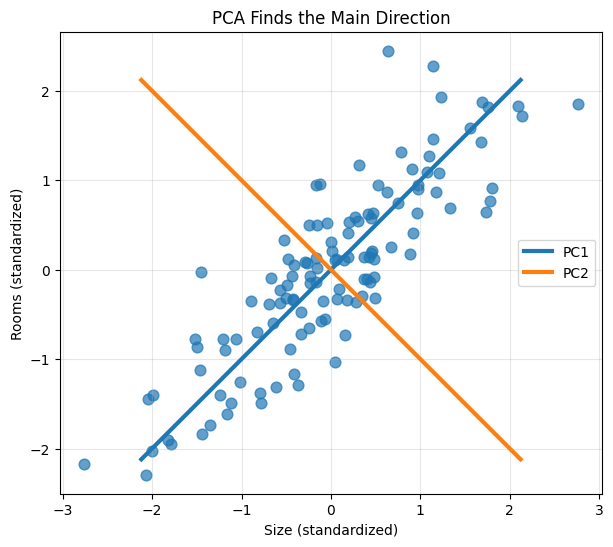

In [7]:
mean = X_scaled.mean(axis=0)

pc1 = pca.components_[0]
pc2 = pca.components_[1]

t = np.linspace(-3, 3, 100)

pc1_line = mean + t[:, None] * pc1
pc2_line = mean + t[:, None] * pc2


plt.figure(figsize=(7,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    s=60,
    alpha=0.7
)

plt.plot(
    pc1_line[:,0],
    pc1_line[:,1],
    linewidth=3,
    label="PC1"
)
plt.plot(
    pc2_line[:,0],
    pc2_line[:,1],
    linewidth=3,
    label="PC2"
)

plt.xlabel("Size (standardized)")
plt.ylabel("Rooms (standardized)")

plt.title("PCA Finds the Main Direction")

plt.legend()

plt.grid(True, alpha=0.3)

plt.axis("equal")

plt.show()

### Questions

1. Why does PCA choose this direction?
    -> Because the first direction, it always find the longest spread
2. What does “maximum variance” mean visually?
    -> The large the spreadout of two data point 
3. Why is this direction informative?
    -> Because it show a lot of difference between the number of room with the difference size

## Part D — Reduce to One Dimension

In [19]:
pca_1d = PCA(n_components=1)

X_reduced = pca_1d.fit_transform(X_scaled)

print(X_reduced.shape)

(120, 1)


### Before vs After PCA

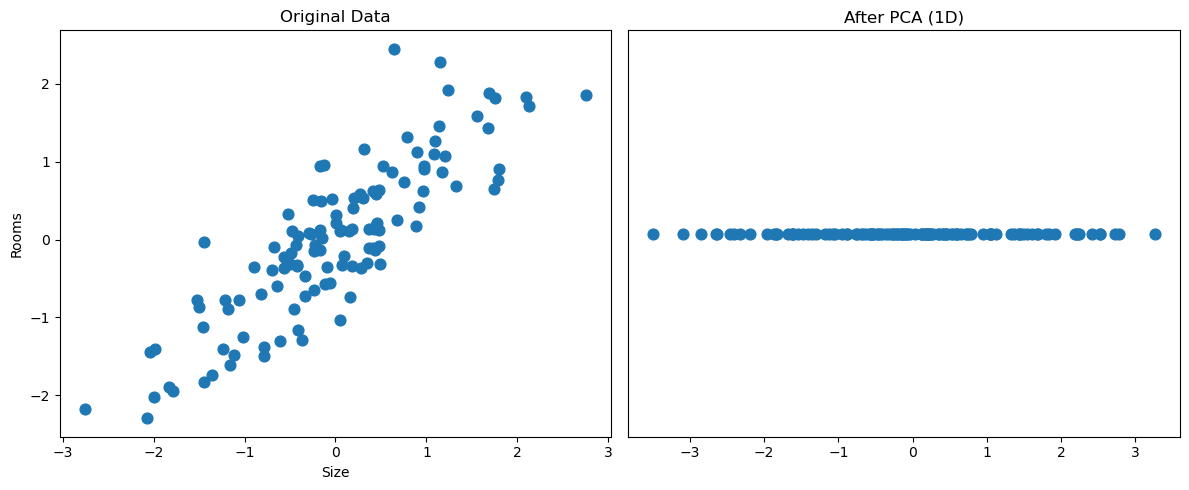

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Original
axes[0].scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    s=60
)

axes[0].set_title("Original Data")
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Rooms")

# Reduced
axes[1].scatter(
    X_reduced[:,0],
    np.zeros_like(X_reduced[:,0]),
    s=60
)

axes[1].set_title("After PCA (1D)")
axes[1].set_yticks([])

plt.tight_layout()

plt.show()

Even after reducing dimensions: `similar apartments stay close together`

PCA compresses the data while preserving important relationships.

## Part E — Real Dataset

Now apply PCA to a real dataset.

Choose one dataset from the table below.

| Dataset | Link | Features | What PCA can help with |
|---|---|---|---|
| Iris | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) | flower measurements | visualize species in 2D |
| Wine | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) | chemical properties | reduce many chemical features |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | tumor measurements | visualize benign vs malignant cases |
| Digits | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) | image pixels | compress image features |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | biological measurements | visualize species groups |
| Wine Quality | [Open dataset](https://archive.ics.uci.edu/dataset/186/wine+quality) | chemical properties | reduce correlated wine features |

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()
iris.keys()



dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [11]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [8]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target
print(X)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

### Apply PCA to 2D

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Visualize Reduced Data

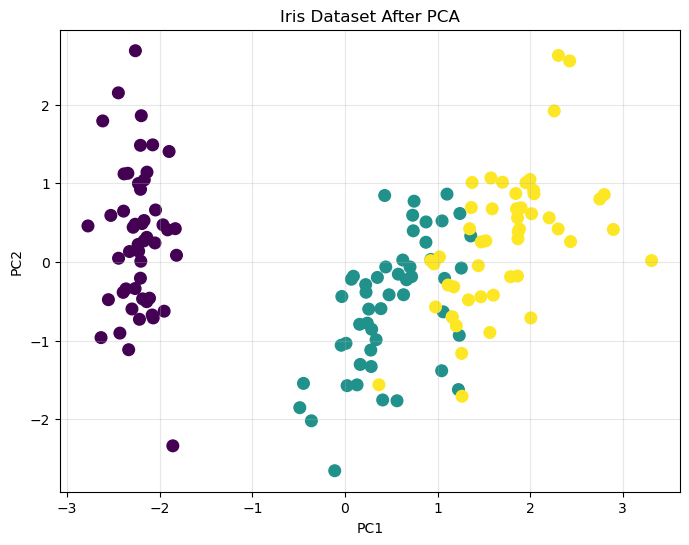

In [23]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    s=70
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Iris Dataset After PCA")

plt.grid(True, alpha=0.3)

plt.show()

### Questions

1. Do the classes separate well?
-> 
2. Which species overlap?
-> 
3. Why is PCA useful for visualization?
-> 
4. Why can PCA help machine learning models?
-> 

## Part F — Train a Model with Logistic Regression and PCA


Look in the previous exercises and find how to load a dataset, separate it in train/dev/test or just train/dev datasets. 

1. Use [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) or [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) depending on the task to train and test a model. Please report accuracy, precision and recall.
2. Use then PCA to reduce the dimensionality of the data, and redo step 1. Report metrics and see the difference. Is there any?

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import umap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [31]:
dataset = load_dataset('imodels/diabetes-readmission', split="train")
df = dataset.to_pandas()

summary = df.describe()
print(summary)

       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count      81410.000000        81410.000000    81410.000000     81410.000000   
mean           4.402383           43.079511        1.340400        16.020993   
std            2.985910           19.688887        1.707738         8.128563   
min            1.000000            1.000000        0.000000         1.000000   
25%            2.000000           31.000000        0.000000        10.000000   
50%            4.000000           44.000000        1.000000        15.000000   
75%            6.000000           57.000000        2.000000        20.000000   
max           14.000000          132.000000        6.000000        81.000000   

       number_outpatient  number_emergency  number_inpatient  \
count       81410.000000      81410.000000      81410.000000   
mean            0.368849          0.198207          0.634922   
std             1.264143          0.936837          1.262987   
min             0.00000

In [33]:
numeric_cols = [
    "time_in_hospital", "num_lab_procedures", "num_procedures", 
    "num_medications", "number_outpatient", "number_emergency", 
    "number_inpatient", "number_diagnoses"
]

categorical_cols = [
    "age",                      
    "discharge_disposition_id", 
    "admission_source_id"       
]

Y_column = 'readmitted'

df = df.dropna() 
y = df[Y_column]

df[categorical_cols] = df[categorical_cols].astype(str)
x_combined = pd.get_dummies(df[numeric_cols + categorical_cols], drop_first=True)



KeyError: "None of [Index(['age', 'discharge_disposition_id', 'admission_source_id'], dtype='str')] are in the [columns]"

In [ ]:

scaler = StandardScaler()

x_scaled_raw = scaler.fit_transform(x_combined)
x_scaled = pd.DataFrame(x_scaled_raw, columns=x_combined.columns)

pca = PCA(n_components=4)
x_pca = pca.fit_transform(x_scaled)

components_df = pd.DataFrame(
    pca.components_, 
    columns=x_scaled.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)



array([[ 0.52045465,  0.38337064,  0.34383257,  0.56450384,  0.05545154,
         0.04178631,  0.11771841,  0.35579473],
       [-0.06139499, -0.02605961, -0.28415757, -0.08360635,  0.37784839,
         0.59377381,  0.61226234,  0.19394355],
       [-0.2017277 , -0.55855762,  0.58498597,  0.17711815,  0.51015766,
         0.04487526, -0.10706874,  0.00124616],
       [-0.00130049,  0.19131879, -0.37218344, -0.09992244,  0.65295542,
        -0.44174189, -0.26427339,  0.35151575]])

In [6]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.25370901 0.17114866 0.12290511 0.11919292]


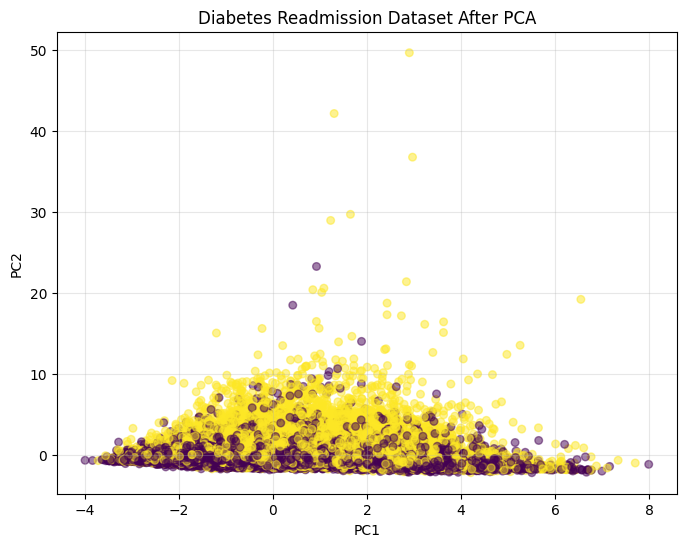

In [10]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=y,
    s=30,
    alpha =0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Diabetes Readmission Dataset After PCA")

plt.grid(True, alpha=0.3)

plt.show()


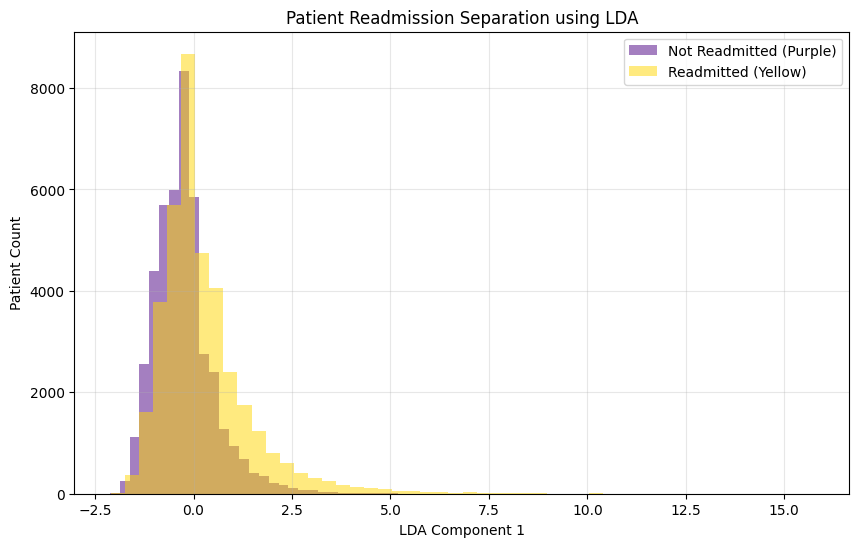

In [14]:
lda = LDA(n_components=1)

x_lda = lda.fit_transform(x_scaled, y)

plt.figure(figsize=(10, 6))

plt.hist(x_lda[y == 0], bins=50, alpha=0.5, label='Not Readmitted (Purple)', color='indigo')
plt.hist(x_lda[y == 1], bins=50, alpha=0.5, label='Readmitted (Yellow)', color='gold')

plt.xlabel('LDA Component 1')
plt.ylabel('Patient Count')
plt.title('Patient Readmission Separation using LDA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

d:\HoangNM\OneDrive - Web-Portal\Documents\GitHub\ml-course\docs\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


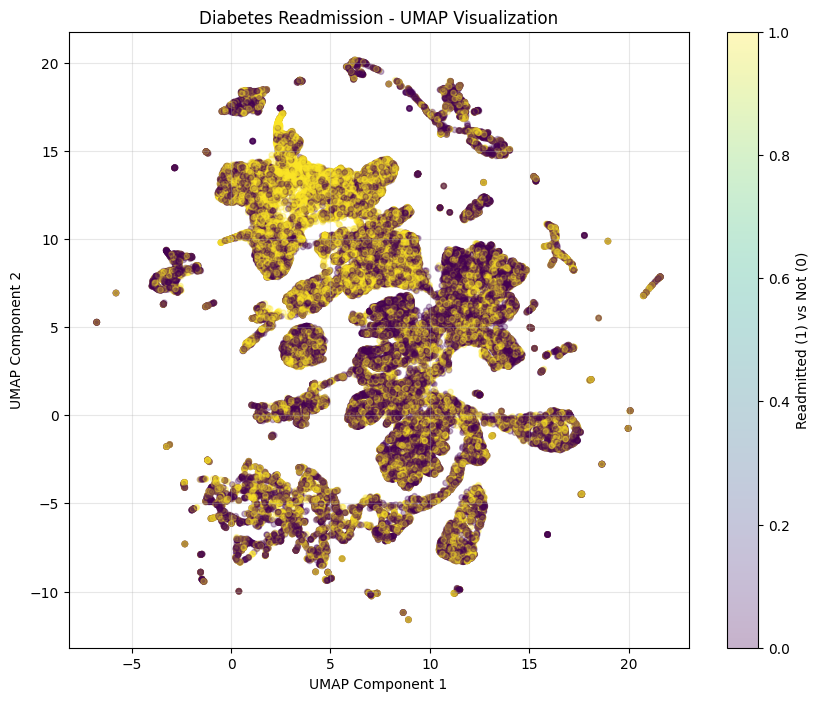

In [16]:
# 1. Initialize UMAP (We want 2D for a scatter plot)
# random_state ensures you get the exact same picture every time you run it
reducer = umap.UMAP(n_components=2, random_state=42)

# 2. Fit and Transform the scaled data
# Note: UMAP can actually use your 'y' labels to help it separate if you want (supervised UMAP),
# but standard UMAP just takes 'x_scaled' like PCA does.
x_umap = reducer.fit_transform(x_scaled)

# 3. Visualize (Exactly like your PCA plot!)
plt.figure(figsize=(10, 8))

# Using alpha=0.3 to help see overlapping densities
scatter = plt.scatter(
    x_umap[:, 0], 
    x_umap[:, 1], 
    c=y, 
    cmap='viridis', 
    s=15, 
    alpha=0.3
)

plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.title("Diabetes Readmission - UMAP Visualization")
plt.colorbar(scatter, label="Readmitted (1) vs Not (0)")

plt.grid(True, alpha=0.3)
plt.show()